In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
!pip install -q transformers accelerate torch torchvision pillow

In [3]:
!pip install -q qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 61.0 MB/s eta 0:00:00


In [4]:
import torch
from PIL import Image

from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor
)

In [5]:
model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [6]:
from google.colab import files

uploaded = files.upload()

Saving image.avif to image.avif


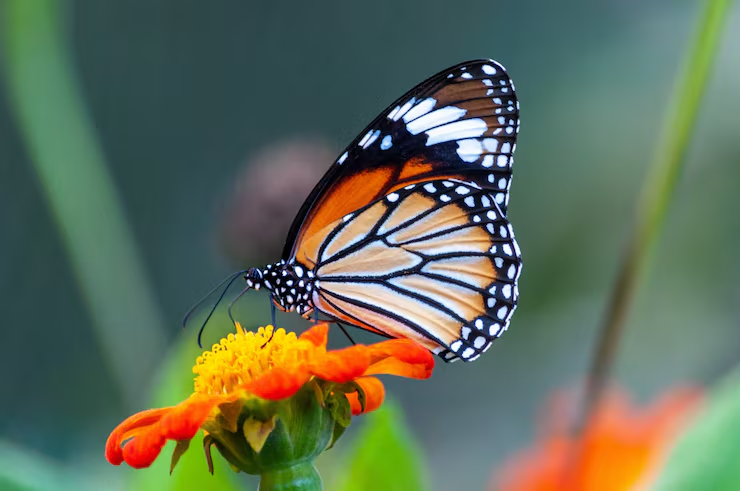

In [7]:
image = Image.open("image.avif")
image

In [8]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image,
            },
            {
                "type": "text",
                "text": "Describe this image in detail."
            }
        ]
    }
]

In [9]:
text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = processor(
    text=[text],
    images=[image],
    padding=True,
    return_tensors="pt"
)

inputs = inputs.to(model.device)

In [11]:
generated_ids = model.generate(
    **inputs,
    max_new_tokens=512
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

response = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True
)

print(response[0])

The image depicts a butterfly perched on the vibrant orange petals of a flower. The butterfly has a striking and colorful pattern, with wings that feature a mix of black, white, and orange hues. The wings are adorned with intricate patterns, including white spots and black lines, which create a visually appealing contrast against the orange background.

The flower itself is a bright orange color, with a yellow center that appears to be densely packed with small, delicate petals. The butterfly's antennae are extended, indicating that it is actively feeding or exploring the flower. The background of the image is blurred, drawing attention to the butterfly and the flower in the foreground. The overall composition highlights the beauty and delicate nature of both the butterfly and the flower.


(np.float64(-0.5), np.float64(739.5), np.float64(490.5), np.float64(-0.5))

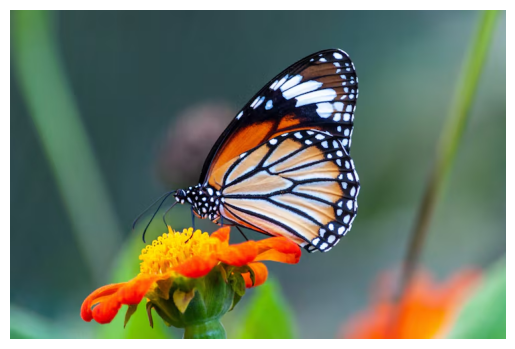

In [12]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.axis("off")